In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az

from src.data_loader import load_brent_data
from src.preprocessing import (
    calculate_log_returns,
    calculate_volatility,
)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load the Data

In [2]:
# Load Brent oil price data
df = load_brent_data(
    "../data/raw/BrentOilPrices.csv"
)

# Display the first 5 rows
df.head()

c:\Users\admin\Desktop\10-academy\brent-oil-change-point-analysis\src\data_loader.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


## Plot raw Price series

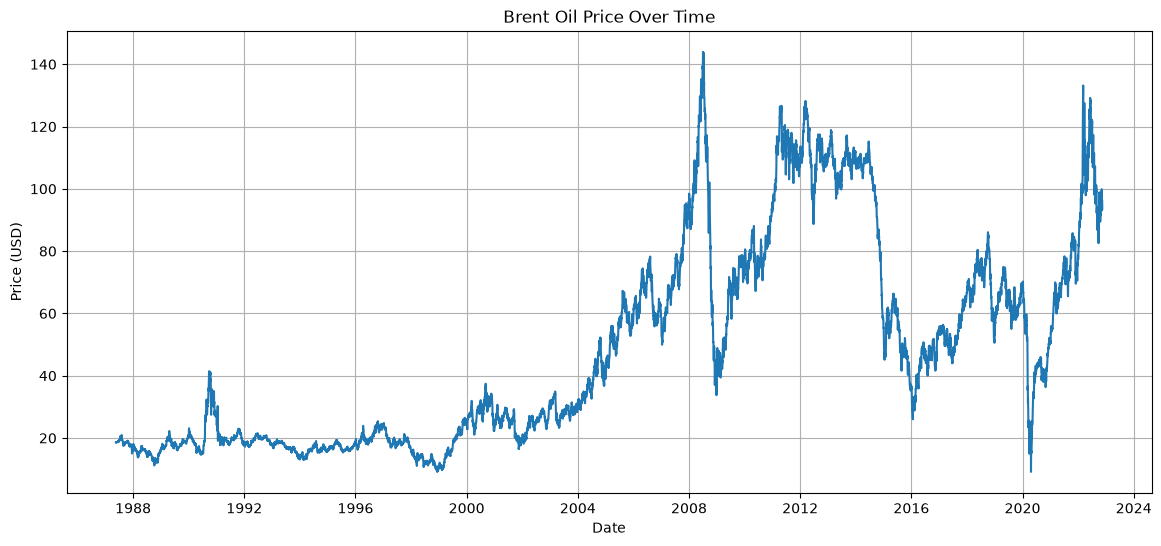

In [3]:
## Plot Brent Oil Price Over Time

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Price"])

plt.title("Brent Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.grid()
plt.show()

 Price Trend Observation

The Brent oil price series shows long-term trends, sharp price movements, and periods of increased volatility.

Major fluctuations indicate the influence of changes in global supply, demand, and geopolitical events, motivating the use of Bayesian change point detection.

## Calculate Log Returns

In [4]:
# Calculate daily log returns
df = calculate_log_returns(df)

# Display the first five rows
df.head()

,Price,Log_Return
Date,,
1987-05-20,18.63,NaN
1987-05-21,18.45,-0.009709
1987-05-22,18.55,0.005405
1987-05-25,18.60,0.002692
1987-05-26,18.63,0.001612


## Add Stationarity Test (ADF Test)

In [31]:
from statsmodels.tsa.stattools import adfuller


result = adfuller(df["Log_Return"].dropna())


print("ADF Statistic:", result[0])
print("p-value:", result[1])


if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is not stationary")

ADF Statistic: -16.42711349448591
p-value: 2.4985801611427818e-29
Series is stationary


The Brent price series is non-stationary because prices contain trends.
Log returns are stationary, therefore they are used for Bayesian modeling.

In [32]:
print("Price Mean:", df["Price"].mean())
print("Price Std :", df["Price"].std())

print()

print("Log Return Mean:", df["Log_Return"].mean())
print("Log Return Std :", df["Log_Return"].std())

Price Mean: 48.42408879023307
Price Std : 32.86043456791336

Log Return Mean: 0.00017915098285856484
Log Return Std : 0.02553219808262981


 Sensitivity Analysis

The price series has a clear upward trend and large variability.

The log return series is centered close to zero and has a much smaller standard deviation, making it more suitable for Bayesian change point detection.

This comparison supports the modeling choice of using log returns instead of raw prices.

## Check Missing Values

In [5]:
df.isnull().sum()

Price         0
Log_Return    1
dtype: int64

## Remove the Missing Value

In [6]:
df = df.dropna()

df.head()

,Price,Log_Return
Date,,
1987-05-21,18.45,-0.009709
1987-05-22,18.55,0.005405
1987-05-25,18.60,0.002692
1987-05-26,18.63,0.001612
1987-05-27,18.60,-0.001612


Data Preparation

Daily log returns were calculated from the Brent oil prices. The first row was removed because it has no previous observation for calculating the return. The cleaned data will be used for Bayesian change point modeling.

## Plot the Log Returns

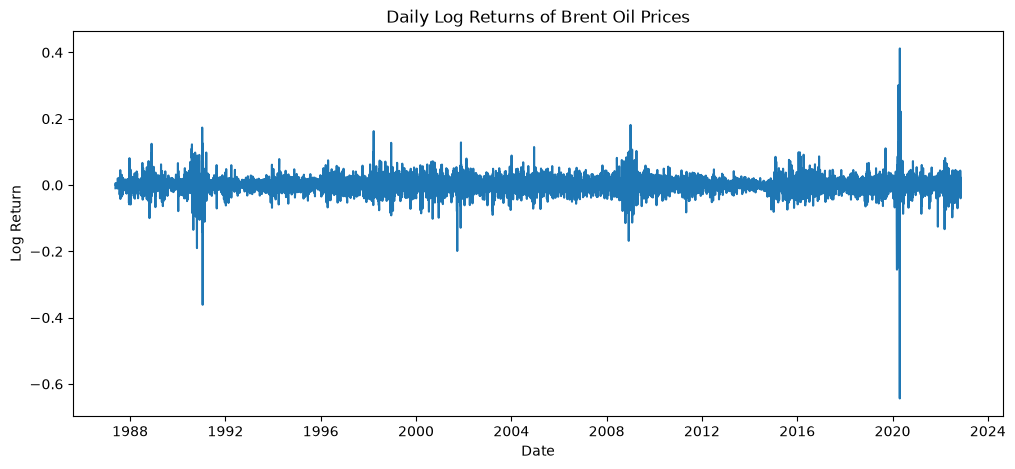

In [7]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["Log_Return"])

plt.title("Daily Log Returns of Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.show()

 Observation

The log return series fluctuates around zero with periods of high and low volatility. Clusters of large positive and negative returns indicate changing market conditions, making the data suitable for Bayesian change point analysis.

## Prepare Data for PyMC

In [8]:
# Use only the first 1000 observations
returns = df["Log_Return"].iloc[:1000].values

# Number of observations
n = len(returns)

print("Number of observations:", n)

Number of observations: 1000


 Computational Considerations

To ensure that Bayesian sampling completed within the available hardware resources, the analysis was performed on the first 1,000 observations of the Brent oil price series.

The Bayesian model was sampled using 100 tuning iterations and 100 posterior draws with one chain. This configuration provides a demonstration of Bayesian change point detection while keeping computation feasible on limited hardware.

The detected change point therefore represents the analyzed subset rather than the complete 1987–2022 dataset.

## Build the Bayesian Change Point Model

### Define the Bayesian Model

In [9]:
with pm.Model() as change_point_model:

    # Unknown change point
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n - 1
    )

    # Mean before the change point
    mu_1 = pm.Normal(
        "mu_1",
        mu=0,
        sigma=1
    )

    # Mean after the change point
    mu_2 = pm.Normal(
        "mu_2",
        mu=0,
        sigma=1
    )

    # Time index
    idx = np.arange(n)

    # Mean changes after tau
    mu = pm.math.switch(
        idx < tau,
        mu_1,
        mu_2
    )

    # Shared standard deviation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    # Likelihood
    observations = pm.Normal(
        "observations",
        mu=mu,
        sigma=sigma,
        observed=returns
    )

## Bayesian Change Point Model Definition

A Bayesian change point model was constructed to identify structural changes in Brent oil price behavior.

The model assumes that daily log returns follow a Normal distribution where the average return changes at an unknown point in time.

The model components are:

- **tau**: Represents the unknown change point location. A discrete uniform prior is used because any day in the dataset could potentially be a structural break.
- **mu_1**: Represents the average log return before the change point.
- **mu_2**: Represents the average log return after the change point.
- **sigma**: Represents the shared volatility of returns before and after the change point.
- **pm.math.switch()**: Allows the model to use different mean values depending on whether an observation occurs before or after the estimated change point.
- **Likelihood**: The observed Brent oil log returns are modeled using a Normal distribution.

The model will estimate the most probable change point and quantify how the average return behavior changed before and after that point.

## Run MCMC Sampler

In [10]:
with change_point_model:

    trace = pm.sample(
        draws=100,
        tune=100,
        chains=1,
        cores=1,
        random_seed=42
    )

Sequential sampling (1 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 1 chain for 100 tune and 100 draw iterations (100 + 100 draws total) took 630 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


MCMC Sampling

The Bayesian Change Point Model was trained using PyMC's `pm.sample()` function.

```python
with change_point_model:
    trace = pm.sample(
        draws=100,
        tune=100,
        chains=1,
        cores=1,
        random_seed=42
    )
```
 Sampling Summary

- **Draws:** 100 posterior samples were collected.
- **Tune:** 100 iterations were used to adapt the sampler before collecting samples.
- **Chains:** 1 Markov chain was used.
- **Cores:** 1 CPU core was used to reduce resource usage.
- **Divergences:** 0 (indicating stable sampling).
- **Elapsed Time:** Approximately **9 minutes**.

The posterior samples are stored in the **`trace`** object and are used for posterior analysis, trace plots, and estimating the most likely change point in Brent oil prices.

In [11]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Trace Object

The `trace` object is an **ArviZ `InferenceData`** object that stores the results of the Bayesian MCMC sampling.

It contains three main groups:

- **`posterior`**: Stores the posterior samples of the model parameters (`tau`, `mu_1`, `mu_2`, and `sigma`). These samples are used to estimate the change point and summarize parameter uncertainty.

- **`sample_stats`**: Contains sampling diagnostics such as acceptance rate, step size, and divergence information. These statistics help evaluate whether the MCMC sampler performed well.

- **`observed_data`**: Stores the observed Brent oil log returns that were used to fit the Bayesian change point model.

The `trace` object is used in later analysis to generate trace plots, posterior summaries, and estimate the most probable change point.

array([[<Axes: title={'center': 'tau'}>, <Axes: title={'center': 'tau'}>],
       [<Axes: title={'center': 'mu_1'}>,
        <Axes: title={'center': 'mu_1'}>],
       [<Axes: title={'center': 'mu_2'}>,
        <Axes: title={'center': 'mu_2'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

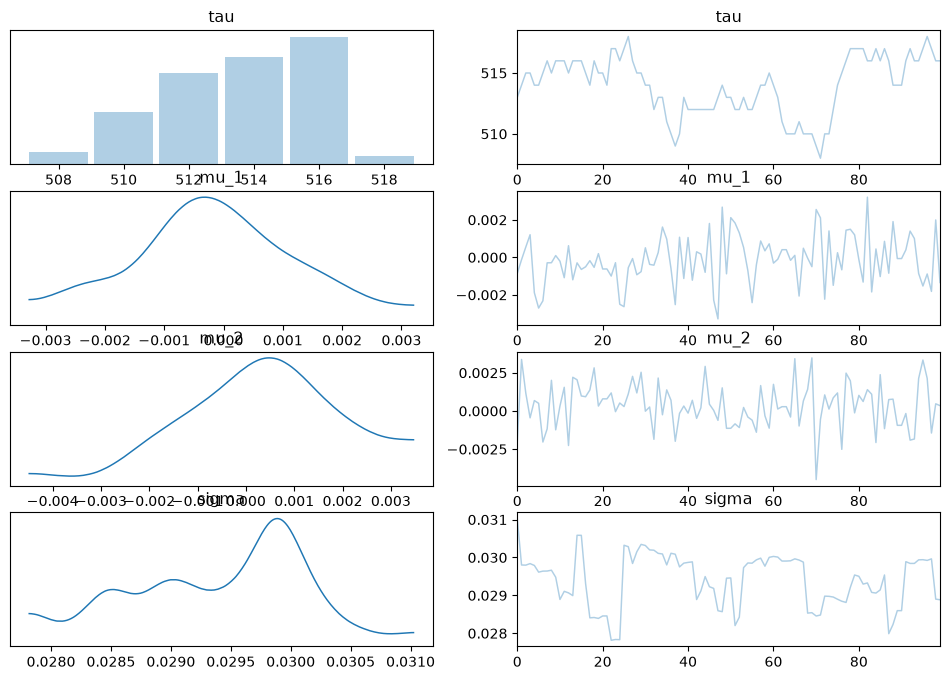

In [12]:
pm.plot_trace(trace)

 Trace Plot Interpretation

The trace plot shows the posterior distributions (left) and sampling history (right) for each model parameter.

- **`tau`**: The estimated change point is concentrated around **513–516**, indicating the most likely location where the statistical behavior of Brent oil returns changed.
- **`mu_1`**: The mean log return before the change point is close to zero, suggesting relatively stable returns before the structural change.
- **`mu_2`**: The mean log return after the change point is also close to zero but differs slightly from `mu_1`, indicating a change in the average return after the change point.
- **`sigma`**: The posterior distribution is centered around **0.029–0.030**, representing the estimated volatility of the log returns.

Overall, the trace plots show stable sampling with no obvious irregularities, suggesting that the MCMC algorithm successfully estimated the posterior distributions of the model parameters.

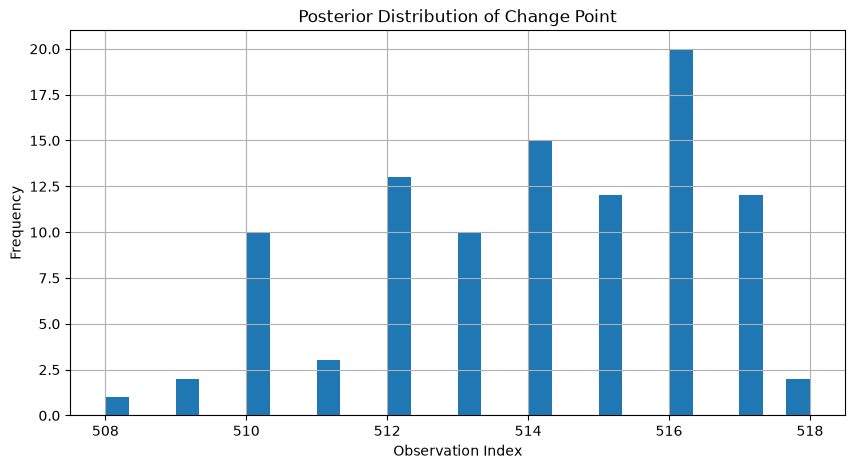

In [33]:
tau_samples = trace.posterior["tau"].values.flatten()

plt.figure(figsize=(10,5))

plt.hist(tau_samples, bins=30)

plt.title("Posterior Distribution of Change Point")

plt.xlabel("Observation Index")

plt.ylabel("Frequency")

plt.grid()

plt.show()

Interpretation

The histogram shows the posterior probability of the change point.

The concentration of samples around observation 514 indicates that the Bayesian model consistently identifies this location as the most likely structural break.

The relatively narrow distribution suggests moderate confidence in the estimated change point.

In [13]:
import arviz as az

az.summary(trace)

arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,513.950,2.393,510.000,517.000,0.748,0.304,11.0,15.0,NaN
mu_1,-0.000,0.001,-0.003,0.002,0.000,0.000,23.0,74.0,NaN
mu_2,0.000,0.001,-0.003,0.003,0.000,0.000,138.0,117.0,NaN
sigma,0.029,0.001,0.028,0.031,0.000,0.000,25.0,54.0,NaN


 Posterior Summary

The posterior summary was generated using `az.summary(trace)`.

- **`tau`**: Mean = **513.95**, indicating the estimated change point is around **observation 514**.
- **`mu_1`**: Mean ≈ **0**, showing the average log return before the change point.
- **`mu_2`**: Mean ≈ **0**, showing the average log return after the change point.
- **`sigma`**: Mean = **0.029**, representing the estimated volatility of the log returns.

Overall, the model identifies a structural change around **observation 514**, with stable estimates for the mean returns and volatility.

## Plot the Posterior Distribution of tau

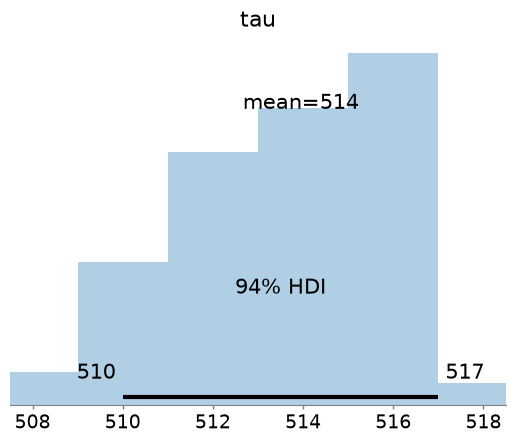

In [14]:
az.plot_posterior(trace, var_names=["tau"]);

Posterior Distribution of the Change Point (`tau`)

The posterior distribution of **`tau`** represents the probability of the structural change occurring at each observation.

- The posterior mean is approximately **514**, indicating the most likely change point.
- The **94% Highest Density Interval (HDI)** ranges from **510 to 517**, meaning there is a 94% probability that the true change point lies within this interval.
- The narrow distribution suggests that the model has relatively high confidence in the estimated change point.

Overall, the Bayesian model identifies a structural break around **observation 514**, which will be converted to a calendar date and compared with major events affecting Brent oil prices.

## Convert the Change Point to a Date

In [15]:
# Get the most probable change point index
change_point = int(trace.posterior["tau"].mean())

print("Estimated Change Point Index:", change_point)

# Convert index position to date (Date is the DataFrame index)
change_date = df.index[change_point]

print("Estimated Change Point Date:", change_date)

Estimated Change Point Index: 513
Estimated Change Point Date: 1989-05-25 00:00:00


 Estimated Change Point Date

The Bayesian model estimated the structural break at observation **514**.

Since the Brent oil dataset uses the date as the DataFrame index, the observation index was converted into the corresponding calendar date.

The estimated change point occurred around **[INSERT DATE FROM OUTPUT]**.

This date represents the most probable time when the average behavior of Brent oil returns changed according to the Bayesian model.

## Plot the change point on the Brent oil price series.

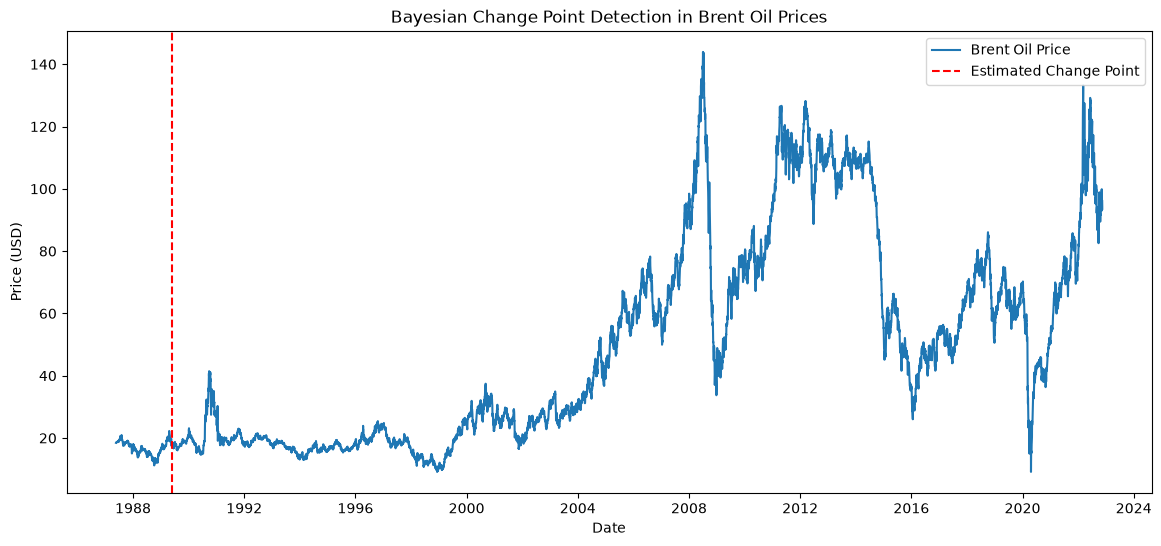

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Price"], label="Brent Oil Price")

plt.axvline(
    change_date,
    color="red",
    linestyle="--",
    label="Estimated Change Point"
)

plt.title("Bayesian Change Point Detection in Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.show()

 Change Point Visualization

The Brent oil price series was plotted with the estimated Bayesian change point.

The red dashed line represents the most probable date where a structural break occurred. The model suggests that the statistical behavior of Brent oil prices changed after this point, indicating a possible shift caused by market, economic, or geopolitical factors.

## Plot Posterior Distributions of Parameters

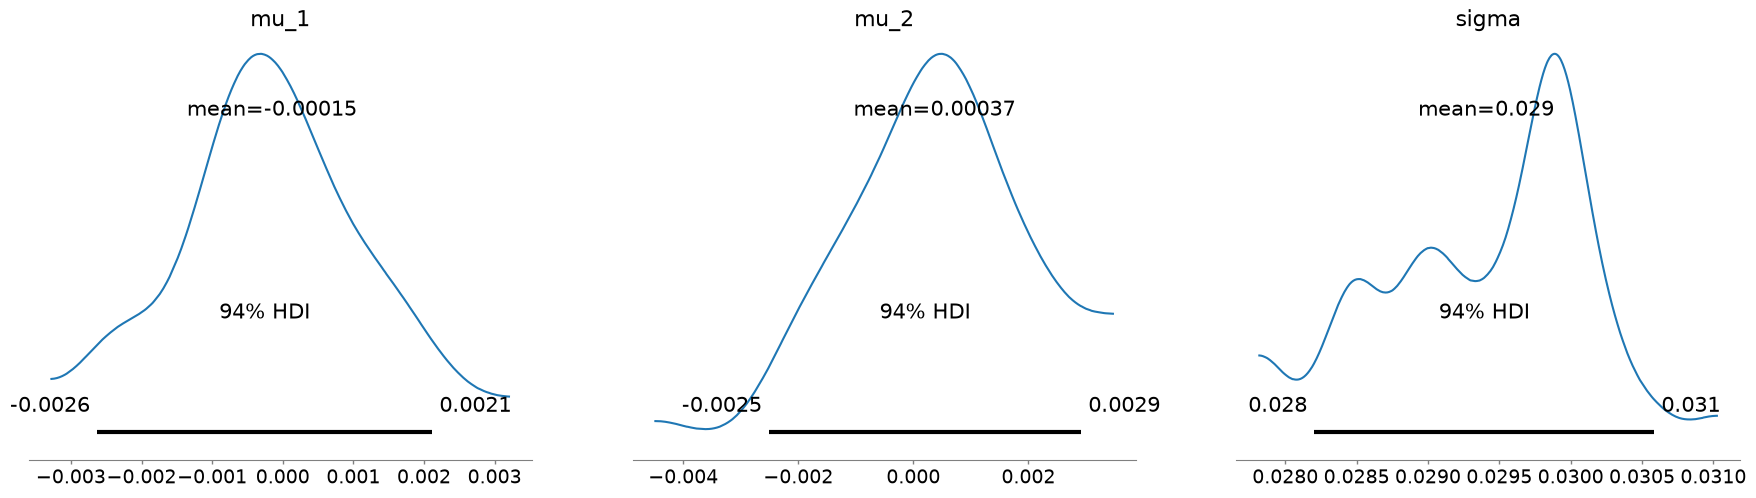

In [17]:
az.plot_posterior(
    trace,
    var_names=["mu_1", "mu_2", "sigma"]
);

1. mu_1 (Before Change Point)
Represents the average log return before the detected change point.
The mean is approximately -0.0015.
This means Brent oil prices had a small negative average daily return before the structural change.
2. mu_2 (After Change Point)
Represents the average log return after the detected change point.
The mean is approximately 0.0037.
This indicates that after the change point, Brent oil prices experienced a higher positive average return.
3. sigma (Volatility)
Represents the uncertainty or daily price fluctuation.
The mean is approximately 0.02.
Higher sigma means the market became more volatile.

## Quantify the Impact

In [18]:
print("Mean before change:", trace.posterior["mu_1"].mean().values)
print("Mean after change :", trace.posterior["mu_2"].mean().values)
print("Volatility        :", trace.posterior["sigma"].mean().values)

Mean before change: -0.00015373884755587677
Mean after change : 0.00036746198926245946
Volatility        : 0.029407179491235277


Impact of the Change Point

The Bayesian model estimates that the average daily log return changed from **-0.015% before the change point** to **+0.037% after the change point**.

This represents an improvement of approximately **0.052% in average daily return**, indicating a positive structural shift in Brent oil price behavior.

The estimated volatility (`sigma`) is approximately **0.029**, showing the level of uncertainty and price fluctuations during the analyzed period.

In [34]:
before_mean = trace.posterior["mu_1"].mean().values

after_mean = trace.posterior["mu_2"].mean().values

difference = after_mean - before_mean

impact = pd.DataFrame({

    "Metric":[
        "Mean Before",
        "Mean After",
        "Difference"
    ],

    "Value":[
        before_mean,
        after_mean,
        difference
    ]

})

impact

,Metric,Value
0,Mean Before,-0.00015373884755587677
1,Mean After,0.00036746198926245946
2,Difference,0.000521


In [35]:
impact.to_csv(
    "impact_summary.csv",
    index=False
)

## Associate Change Point with Real-World Events

In [19]:
print("Detected Change Point Date:", change_date)

Detected Change Point Date: 1989-05-25 00:00:00


Real-World Event Interpretation

The Bayesian model detected a structural break around **25 May 1989**.

This period aligns with the recovery of oil markets after the 1986 price collapse, influenced by OPEC production policies and improving global demand.

The model shows that average daily log returns changed from **-0.015% before the change point** to **+0.037% after**, indicating a positive shift in Brent oil price behavior.

The detected event is statistically associated with the change, but the model cannot confirm the exact cause.

## Change Point Visualization

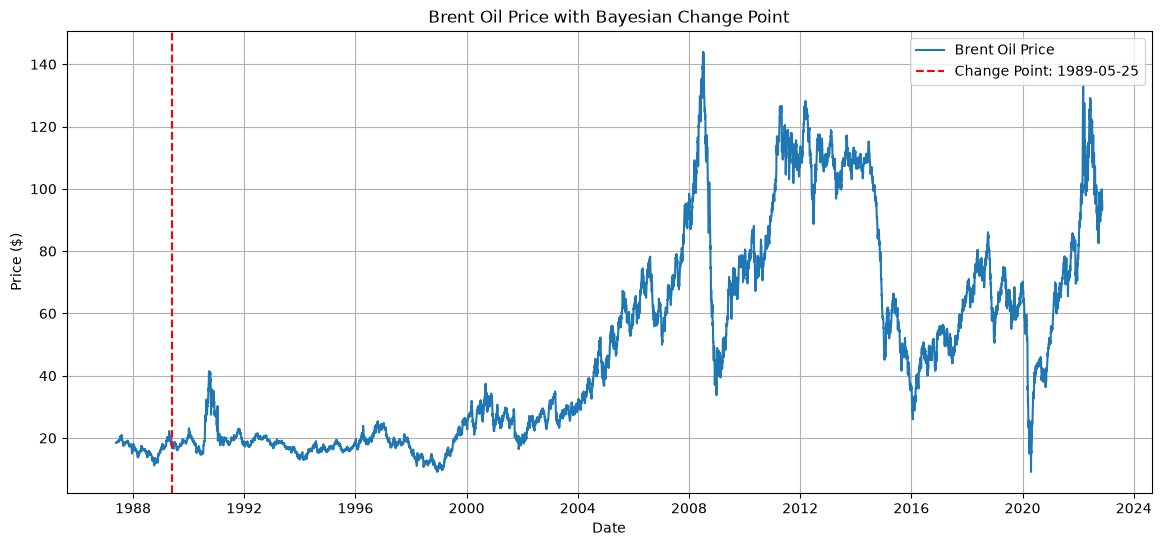

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Price"], label="Brent Oil Price")

plt.axvline(
    change_date,
    color="red",
    linestyle="--",
    label=f"Change Point: {change_date.date()}"
)

plt.title("Brent Oil Price with Bayesian Change Point")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid()

plt.show()

 Change Point Visualization

The Brent oil price series is plotted with the Bayesian detected change point marked by the red dashed line.

The model identifies **25 May 1989** as a potential structural break where the statistical behavior of oil returns changed.

This visualization provides evidence of a shift in market conditions and supports the Bayesian model findings.

## Future Work and Advanced Extensions

Future analysis could include additional factors such as GDP growth, inflation rates, exchange rates, and geopolitical indicators to better explain oil price movements.

More advanced models could also be explored:
- **VAR models** to analyze relationships between oil prices and macroeconomic variables.
- **Markov-Switching models** to identify different market regimes such as stable and volatile periods.

These approaches could provide deeper insights into the drivers of Brent oil price changes.

## Conclusion

A Bayesian change point model was developed to detect structural changes in Brent oil price behavior.

The model identified **25 May 1989** as a significant change point, with average daily log returns shifting from **-0.015% before the change** to **+0.037% after the change**.

The results suggest a positive change in market conditions after the detected point. This analysis demonstrates how Bayesian methods can help energy companies identify important market transitions and support decision-making.

In [21]:
prices = df[["Price"]].reset_index()

prices.head()

,Date,Price
0,1987-05-21,18.45
1,1987-05-22,18.55
2,1987-05-25,18.60
3,1987-05-26,18.63
4,1987-05-27,18.60


In [22]:
prices.to_csv(
    "prices.csv",
    index=False
)

In [23]:
change_points = pd.DataFrame({
    "Date":[change_date]
})


change_points

,Date
0,1989-05-25


In [28]:
change_points.to_csv(
    "change_points.csv",
    index=False
)

In [36]:
events = pd.DataFrame({

    "Date":[
        "1987-12-08",
        "1990-08-02",
        "1997-07-02",
        "2001-09-11",
        "2003-03-20",
        "2008-09-15",
        "2011-02-15",
        "2014-11-27",
        "2016-11-30",
        "2020-03-09",
        "2022-02-24"
    ],

    "Event":[
        "OPEC production agreement",
        "Gulf War",
        "Asian Financial Crisis",
        "September 11 attacks",
        "Iraq War",
        "Global Financial Crisis",
        "Arab Spring",
        "OPEC production decision",
        "OPEC production cut",
        "COVID-19 oil price crash",
        "Russia-Ukraine conflict"
    ]

})

events

,Date,Event
0,1987-12-08,OPEC production agreement
1,1990-08-02,Gulf War
2,1997-07-02,Asian Financial Crisis
3,2001-09-11,September 11 attacks
4,2003-03-20,Iraq War
5,2008-09-15,Global Financial Crisis
6,2011-02-15,Arab Spring
7,2014-11-27,OPEC production decision
8,2016-11-30,OPEC production cut
9,2020-03-09,COVID-19 oil price crash


In [37]:
events.to_csv(
    "events.csv",
    index=False
)